JUDY WAIRIMU NJUKU  
judynjuku7@gmail.com  
FINAL PROJECT PART 1: FAILURE AND TOOL WEAR CLASSIFICATION AND REGRESSION MODELS  

In [1]:
import pandas as pd

try:
    df_p_maintenance = pd.read_csv('p_maintenance.csv')
    print("Successfully loaded p_maintenance.csv")
    print(df_p_maintenance.head())  
except FileNotFoundError:
    print("Error: p_maintenance.csv not found. Please make sure the file is in the correct directory.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

Successfully loaded p_maintenance.csv
   UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0    1     M14860    M                298.1                    308.6   
1    2     L47181    L                298.2                    308.7   
2    3     L47182    L                298.1                    308.5   
3    4     L47183    L                298.2                    308.6   
4    5     L47184    L                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   

   HDF  PWF  OSF  RNF  
0    0    0    0  

In [2]:
print(df_p_maintenance.columns)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')


checking for missing values

In [3]:
missing_values = df_p_maintenance.isnull().sum()
print("Number of missing values per column:")
print(missing_values)

Number of missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


geting basic information about the dataframe

In [4]:
print("Information about the DataFrame:")
df_p_maintenance.info()

print("\nFirst 10 rows of the DataFrame:")
print(df_p_maintenance.head(10))

print("\nDescriptive statistics for numerical columns:")
print(df_p_maintenance.describe())

print("\nUnique values in the 'Type' column:")
print(df_p_maintenance['Type'].unique())

print("\nValue counts for the 'Machine failure' column:")
print(df_p_maintenance['Machine failure'].value_counts())

Information about the DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int

Exploratory Data Analysis(EDA)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

descriptive statistics for numerical columns

In [6]:
print("Descriptive statistics for numerical columns:")
print(df_p_maintenance.describe())

Descriptive statistics for numerical columns:
               UDI  Air temperature [K]  Process temperature [K]  \
count  10000.00000         10000.000000             10000.000000   
mean    5000.50000           300.004930               310.005560   
std     2886.89568             2.000259                 1.483734   
min        1.00000           295.300000               305.700000   
25%     2500.75000           298.300000               308.800000   
50%     5000.50000           300.100000               310.100000   
75%     7500.25000           301.500000               311.100000   
max    10000.00000           304.500000               313.800000   

       Rotational speed [rpm]   Torque [Nm]  Tool wear [min]  Machine failure  \
count            10000.000000  10000.000000     10000.000000     10000.000000   
mean              1538.776100     39.986910       107.951000         0.033900   
std                179.284096      9.968934        63.654147         0.180981   
min              

Distribution of numerical features, (histogram)

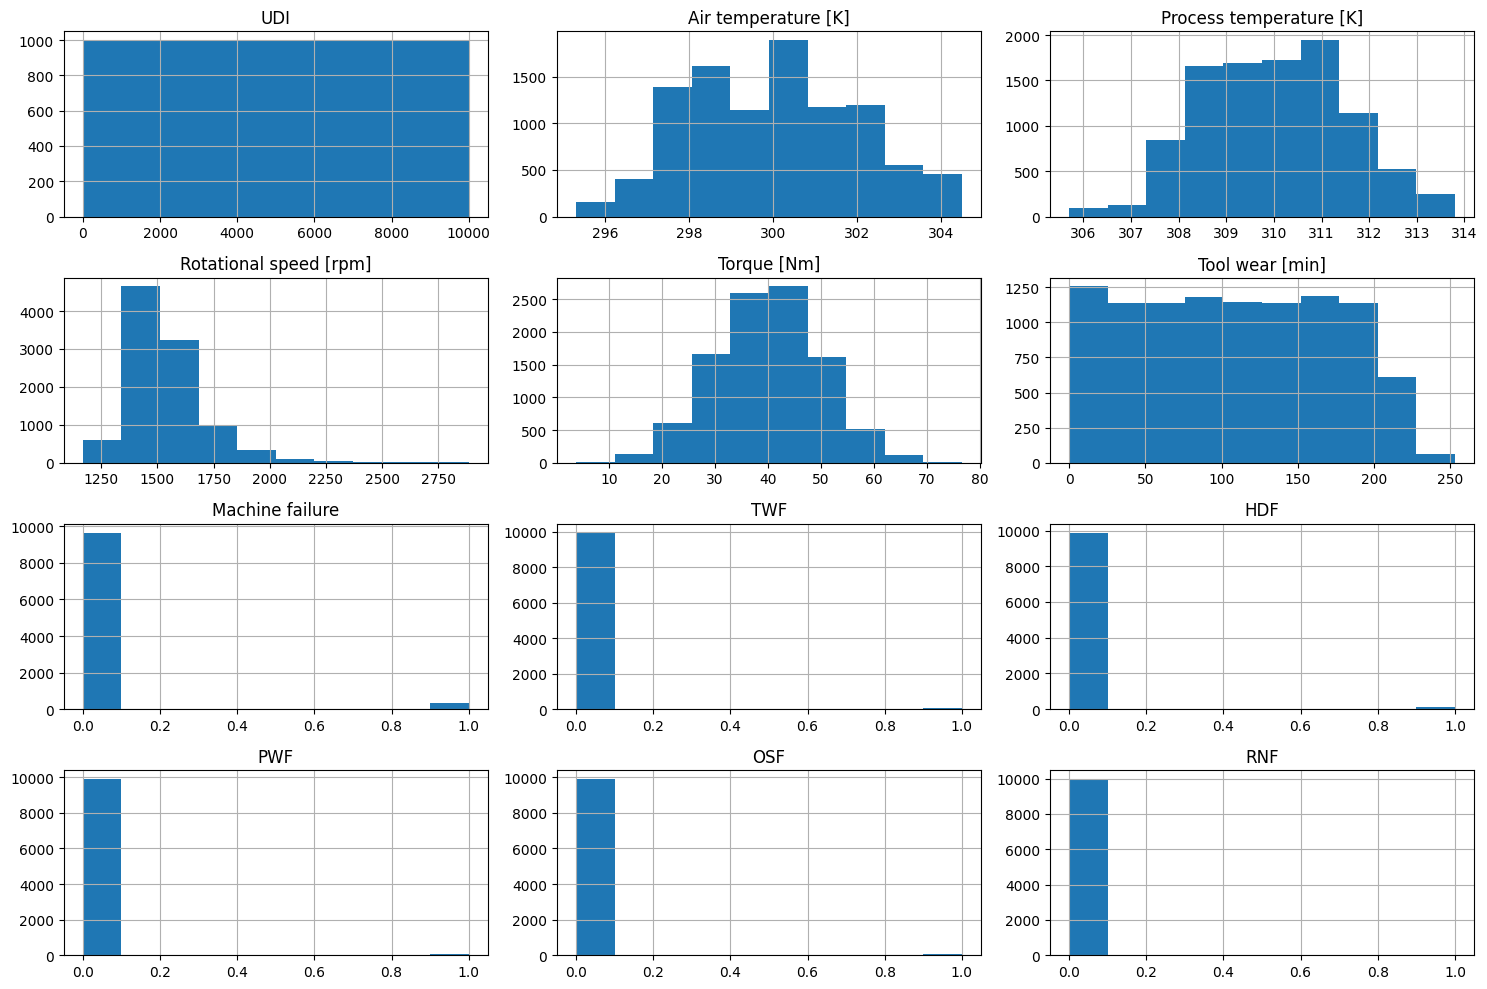

In [7]:
numerical_cols = df_p_maintenance.select_dtypes(include=['number']).columns
df_p_maintenance[numerical_cols].hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

Distribution of numerical features (boxplot)

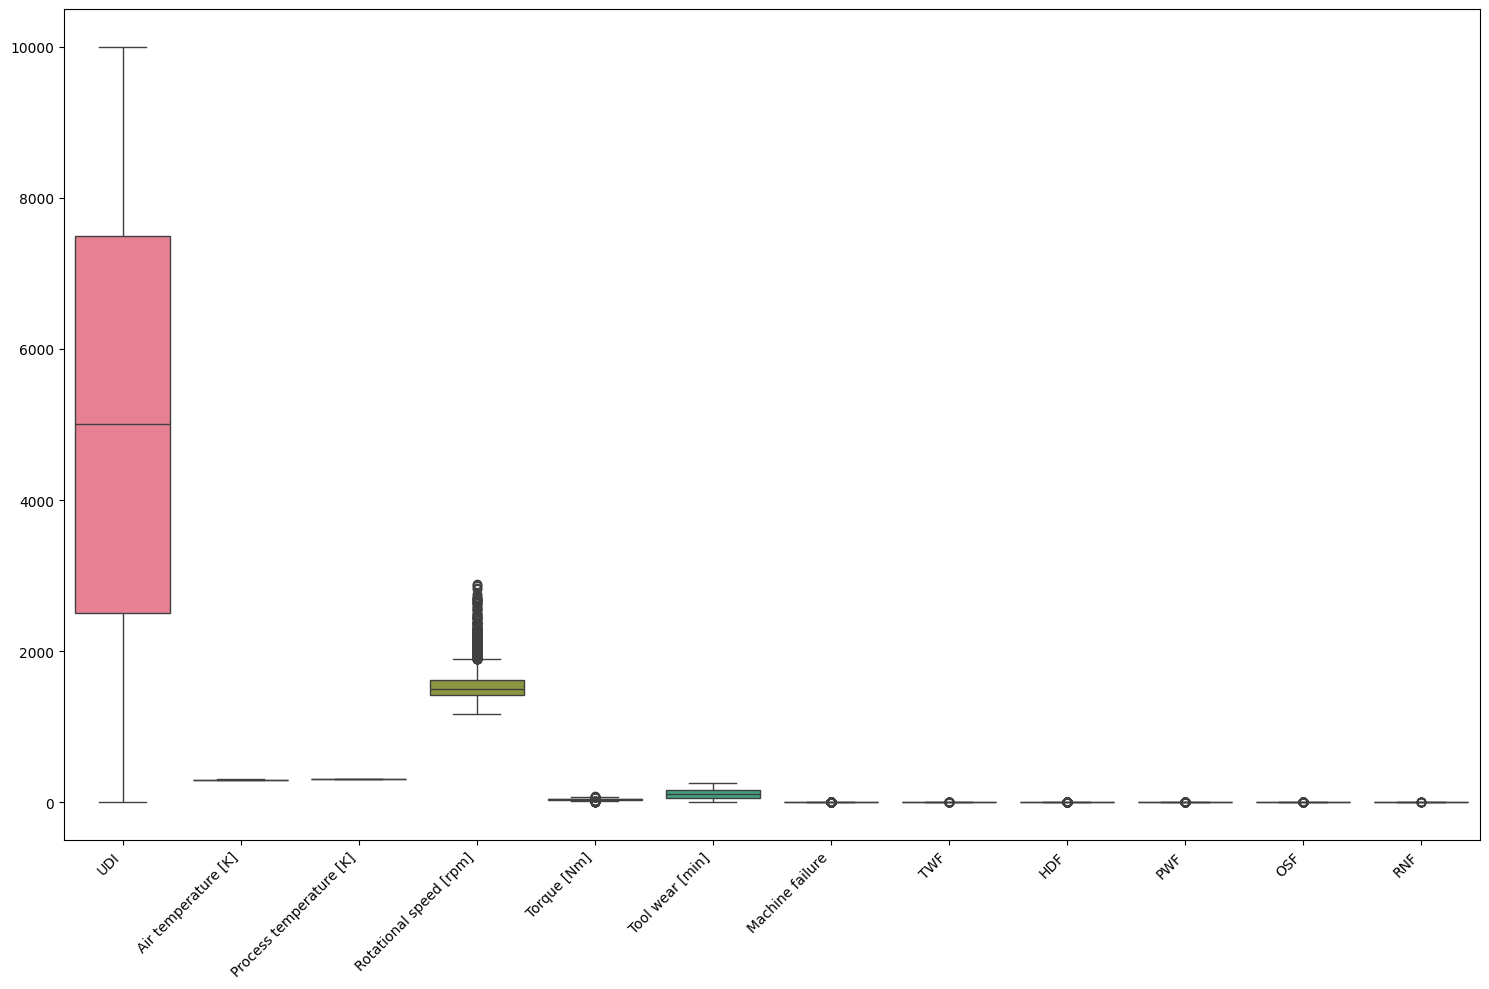

In [8]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df_p_maintenance[numerical_cols])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Analysis of the categorical feature (type)

Value counts for the 'Type' column:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


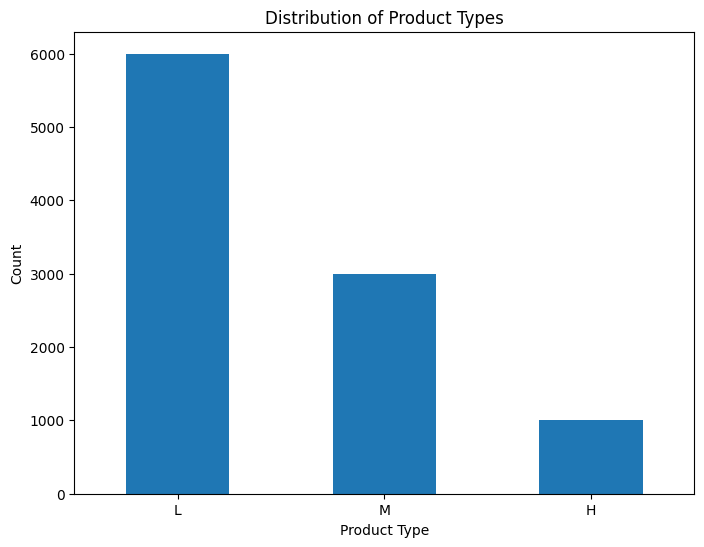

In [9]:
print("Value counts for the 'Type' column:")
print(df_p_maintenance['Type'].value_counts())

plt.figure(figsize=(8, 6))
df_p_maintenance['Type'].value_counts().plot(kind='bar')
plt.title('Distribution of Product Types')
plt.xlabel('Product Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Analysis of the target variable (machine failure)

Value counts for the 'Machine failure' column:
Machine failure
0    9661
1     339
Name: count, dtype: int64


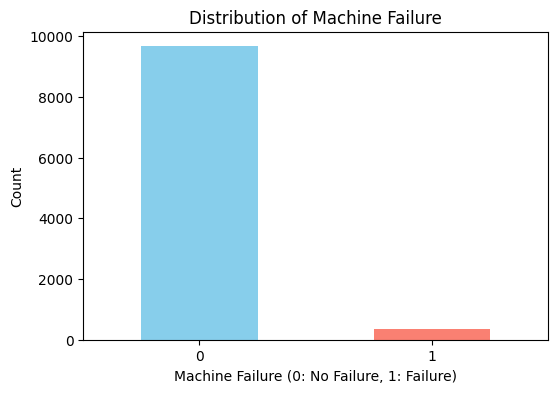

In [10]:
print("Value counts for the 'Machine failure' column:")
print(df_p_maintenance['Machine failure'].value_counts())

plt.figure(figsize=(6, 4))
df_p_maintenance['Machine failure'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Machine Failure')
plt.xlabel('Machine Failure (0: No Failure, 1: Failure)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Correlation Analysis

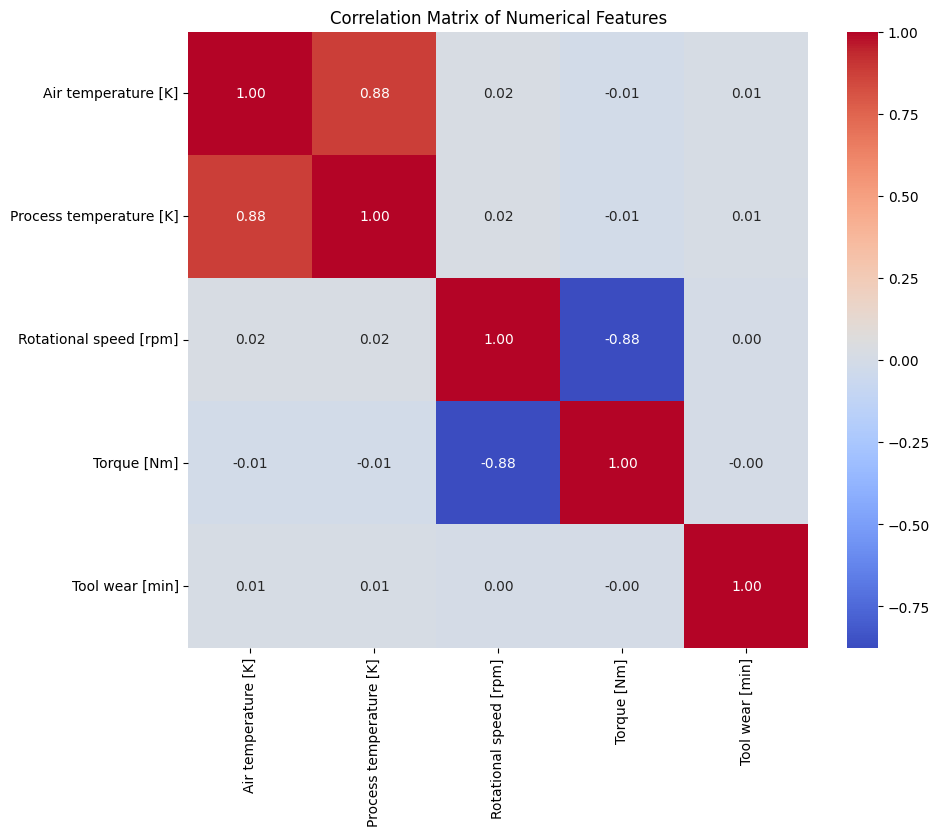


Correlation with 'Machine failure':
Machine failure            1.000000
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64


In [11]:
numerical_cols_for_corr = ['Air temperature [K]', 'Process temperature [K]',
                           'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

correlation_matrix = df_p_maintenance[numerical_cols_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

correlation_with_target = df_p_maintenance[numerical_cols_for_corr + ['Machine failure']].corr()['Machine failure'].sort_values(ascending=False)
print("\nCorrelation with 'Machine failure':")
print(correlation_with_target)

Pair plots

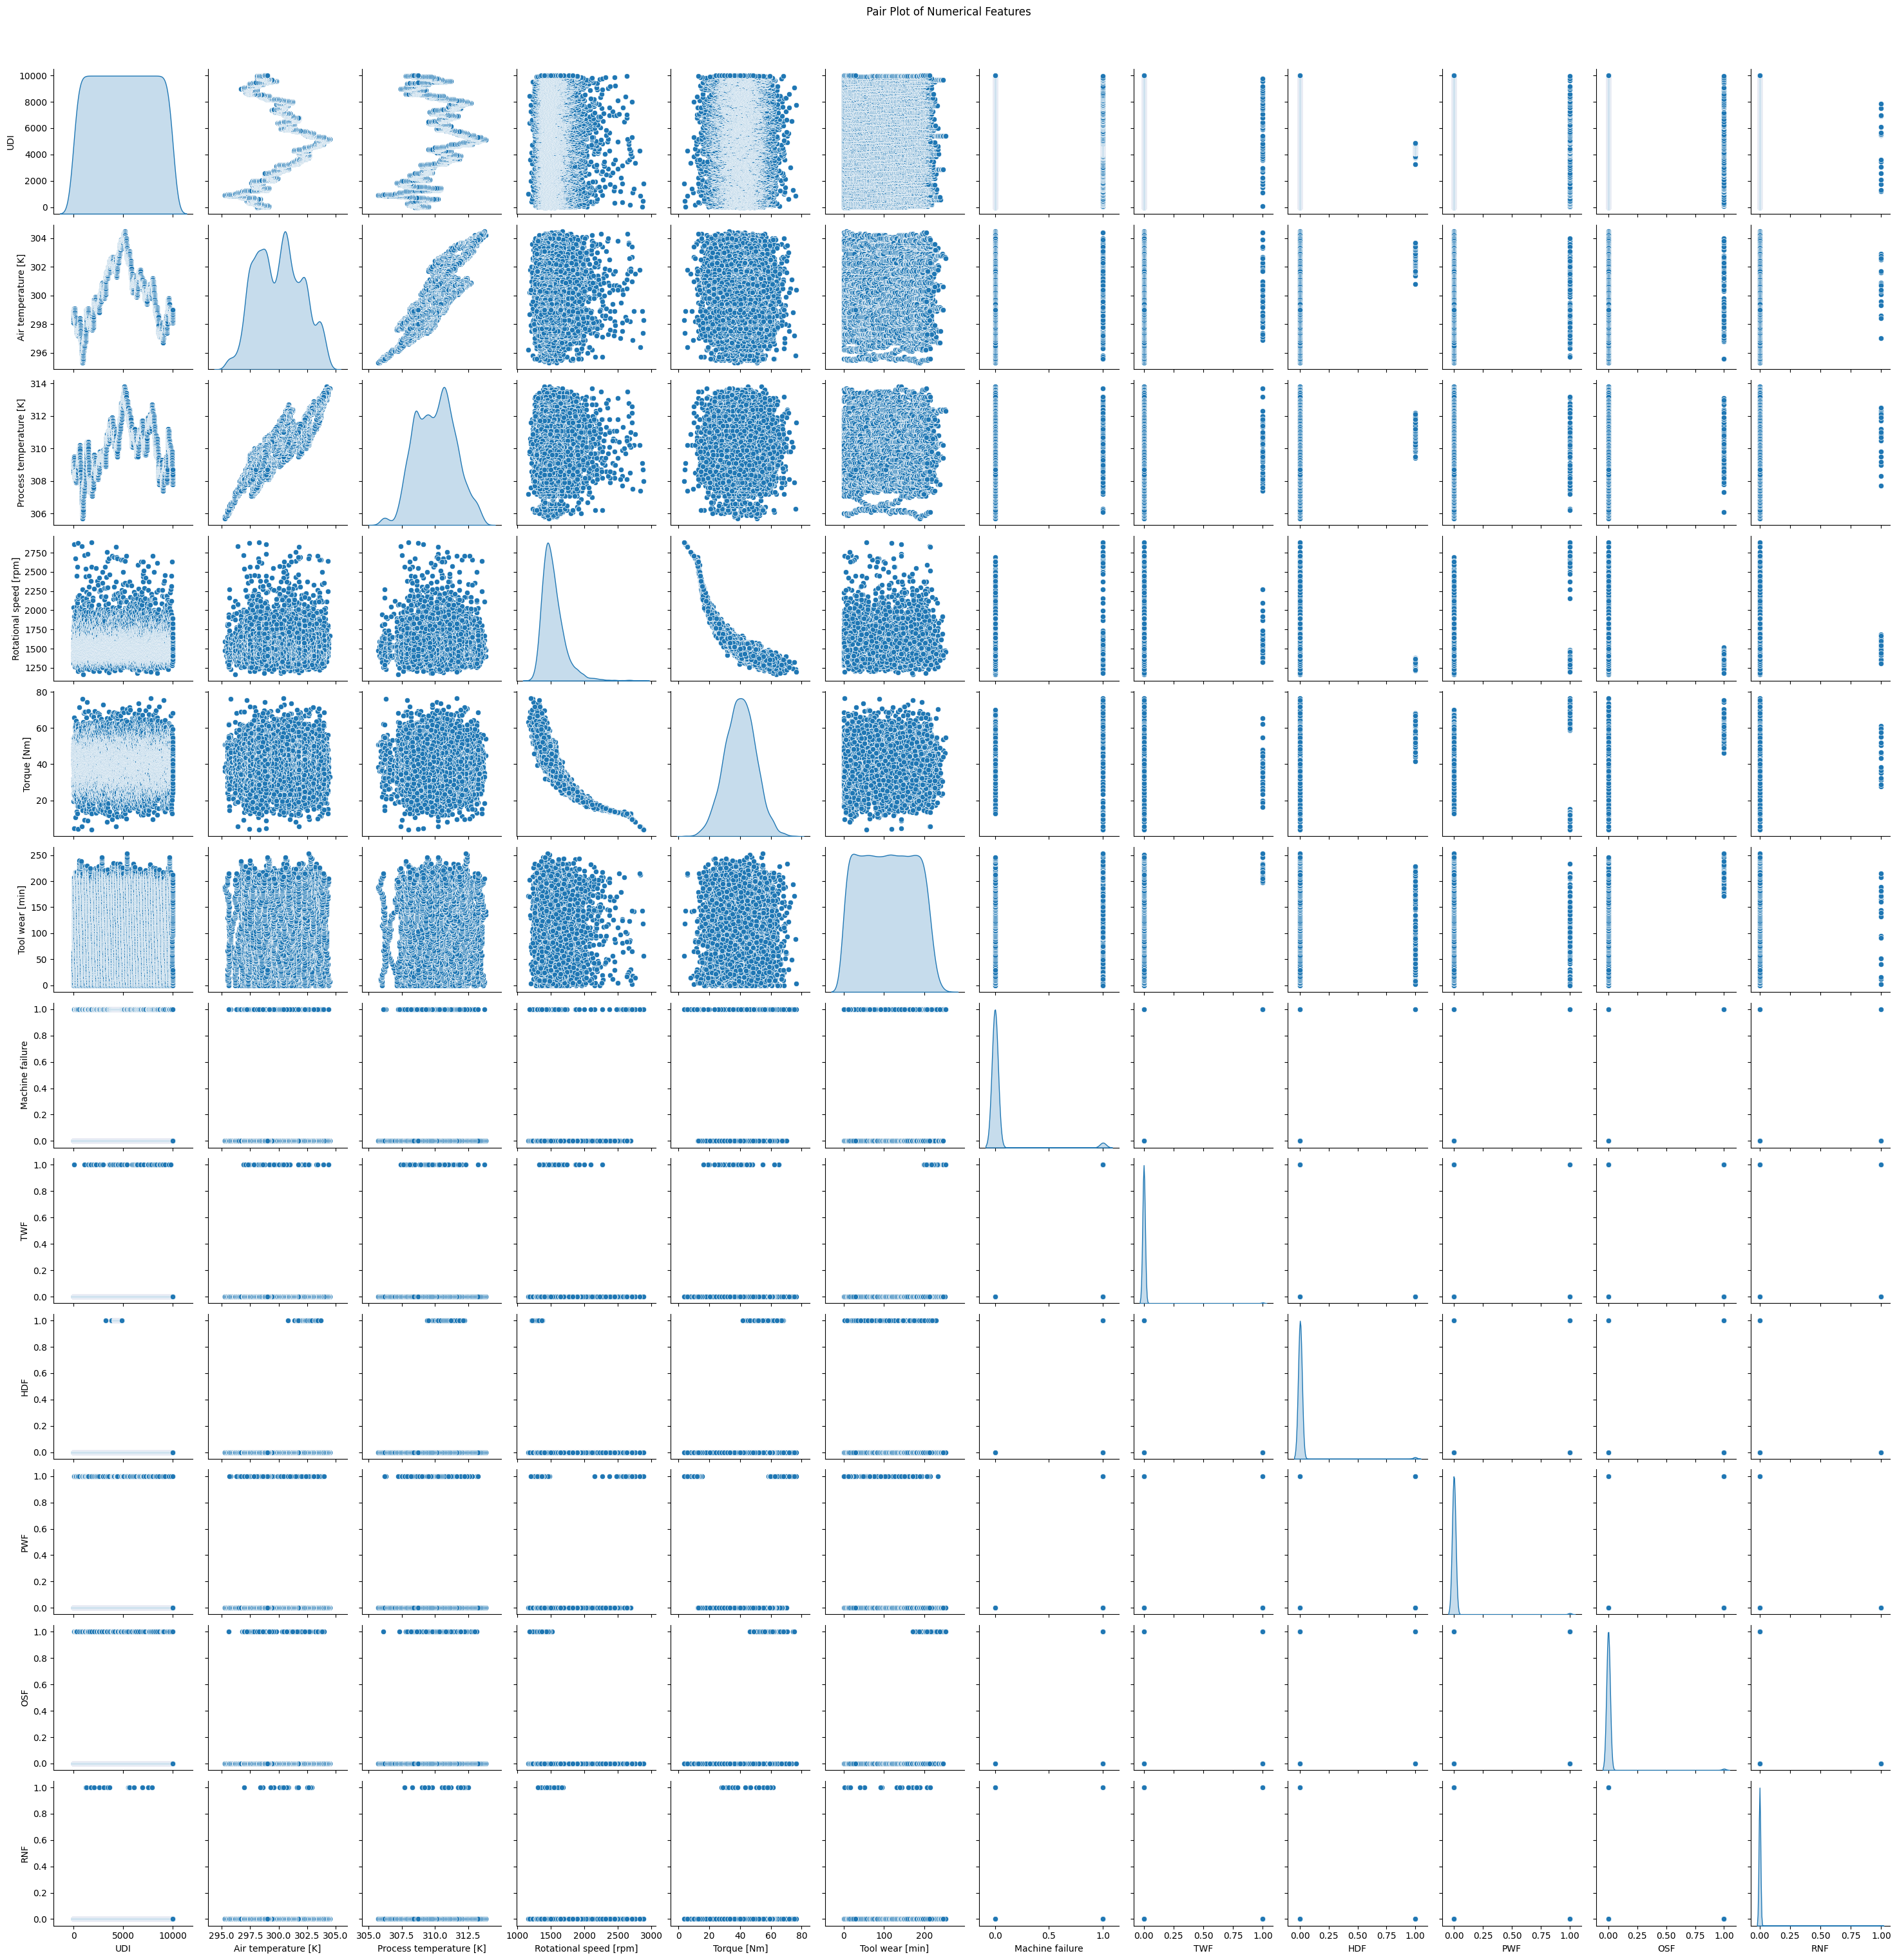

In [12]:
numerical_cols = df_p_maintenance.select_dtypes(include=['number'])
sns.pairplot(numerical_cols, diag_kind='kde')  
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

Exploring relationship between 'Type' and numerical features (group box plots)

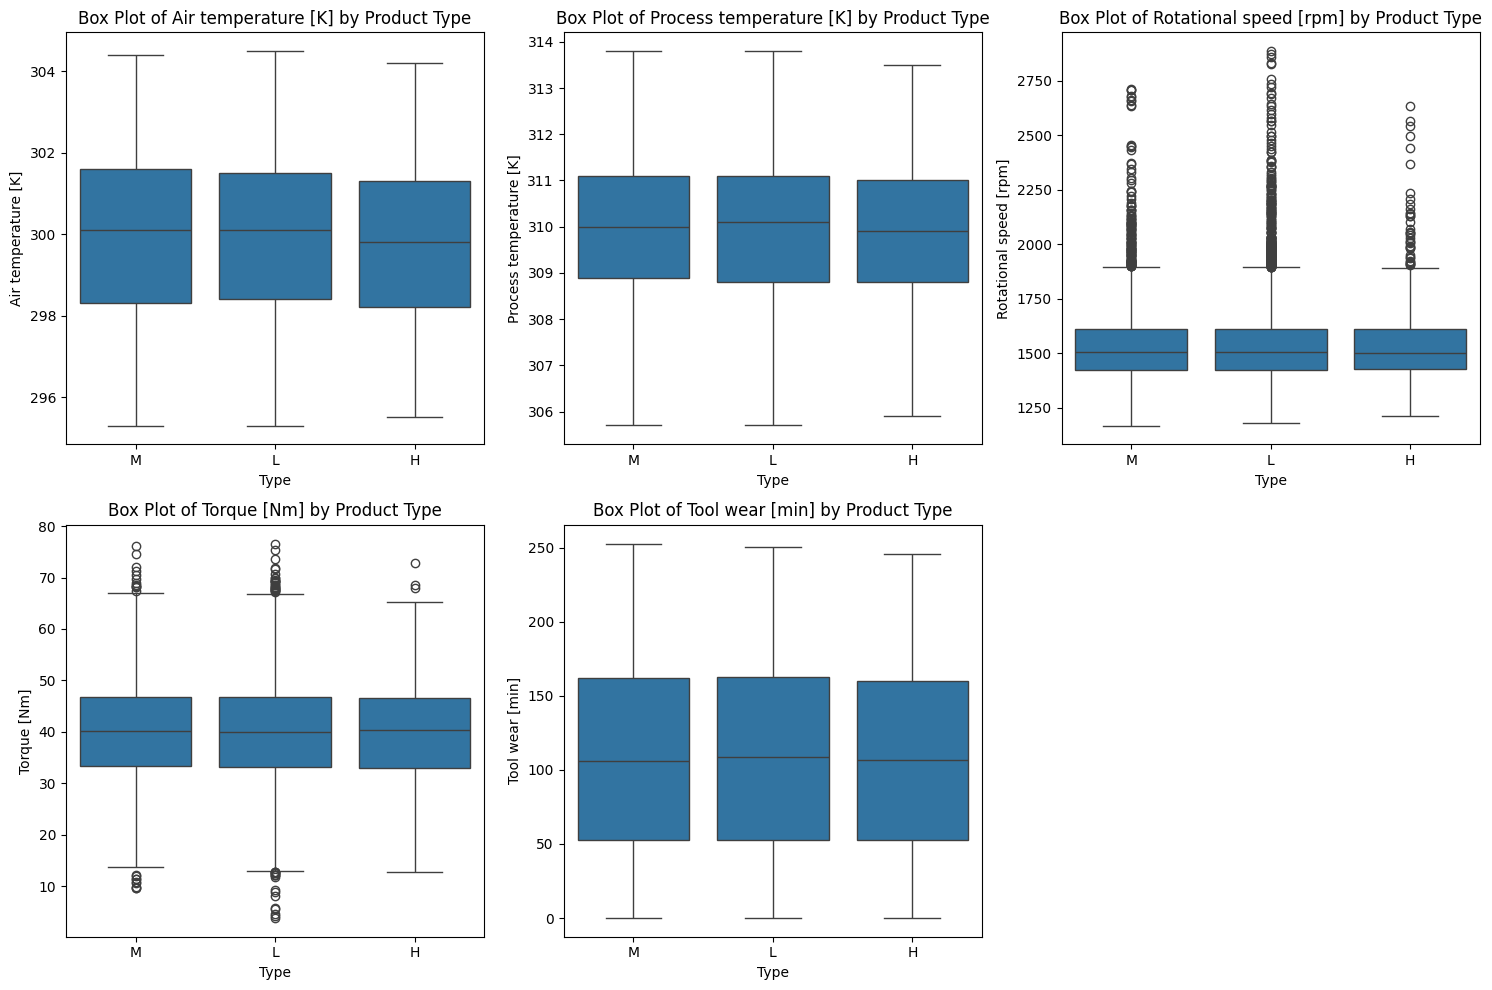

In [13]:
numerical_cols_for_boxplot = ['Air temperature [K]', 'Process temperature [K]',
                              'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_boxplot):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x='Type', y=col, data=df_p_maintenance)
    plt.title(f'Box Plot of {col} by Product Type')
plt.tight_layout()
plt.show()

FEATURE ENGINEERING 

Temperature difference

In [14]:
df_p_maintenance['temp_diff'] = df_p_maintenance['Process temperature [K]'] - df_p_maintenance['Air temperature [K]']
print("DataFrame with 'temp_diff' feature:")
print(df_p_maintenance[['Process temperature [K]', 'Air temperature [K]', 'temp_diff']].head())

DataFrame with 'temp_diff' feature:
   Process temperature [K]  Air temperature [K]  temp_diff
0                    308.6                298.1       10.5
1                    308.7                298.2       10.5
2                    308.5                298.1       10.4
3                    308.6                298.2       10.4
4                    308.7                298.2       10.5


Squared terms (Torque)

In [15]:
df_p_maintenance['torque_squared'] = df_p_maintenance['Torque [Nm]'] ** 2

print("\nDataFrame with 'torque_squared' feature:")
print(df_p_maintenance[['Torque [Nm]', 'torque_squared']].head())


DataFrame with 'torque_squared' feature:
   Torque [Nm]  torque_squared
0         42.8         1831.84
1         46.3         2143.69
2         49.4         2440.36
3         39.5         1560.25
4         40.0         1600.00


squared terms (rotational speed)

In [16]:
df_p_maintenance['rotational_speed_squared'] = df_p_maintenance['Rotational speed [rpm]'] ** 2

print("\nDataFrame with 'rotational_speed_squared' feature:")
print(df_p_maintenance[['Rotational speed [rpm]', 'rotational_speed_squared']].head())


DataFrame with 'rotational_speed_squared' feature:
   Rotational speed [rpm]  rotational_speed_squared
0                    1551                   2405601
1                    1408                   1982464
2                    1498                   2244004
3                    1433                   2053489
4                    1408                   1982464


Torque/Speed ratio

In [17]:
epsilon = 1e-6
df_p_maintenance['torque_speed_ratio'] = df_p_maintenance['Torque [Nm]'] / (df_p_maintenance['Rotational speed [rpm]'] + epsilon)

print("\nDataFrame with 'torque_speed_ratio' feature:")
print(df_p_maintenance[['Torque [Nm]', 'Rotational speed [rpm]', 'torque_speed_ratio']].head())


DataFrame with 'torque_speed_ratio' feature:
   Torque [Nm]  Rotational speed [rpm]  torque_speed_ratio
0         42.8                    1551            0.027595
1         46.3                    1408            0.032884
2         49.4                    1498            0.032977
3         39.5                    1433            0.027565
4         40.0                    1408            0.028409


Correlation of engineered features with target variable 

In [18]:
correlation_with_target_engineered = df_p_maintenance[['temp_diff', 'torque_squared', 'rotational_speed_squared', 'torque_speed_ratio', 'Machine failure']].corr()['Machine failure'].sort_values(ascending=False)
print("\nCorrelation of engineered features with 'Machine failure':")
print(correlation_with_target_engineered)


Correlation of engineered features with 'Machine failure':
Machine failure             1.000000
torque_squared              0.251586
torque_speed_ratio          0.206493
rotational_speed_squared   -0.003852
temp_diff                  -0.111676
Name: Machine failure, dtype: float64


 finding a reasonable proxy for time or order in the dataset

In [19]:
print(f"Number of unique values in 'UDI': {df_p_maintenance['UDI'].nunique()}")

print("\nFirst 20 unique values of 'UDI':")
print(df_p_maintenance['UDI'].unique()[:20])
is_udi_sorted = df_p_maintenance['UDI'].is_monotonic_increasing
print(f"\nIs 'UDI' monotonically increasing? {is_udi_sorted}")

Number of unique values in 'UDI': 10000

First 20 unique values of 'UDI':
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]

Is 'UDI' monotonically increasing? True


Lagged features based on UDI order

In [20]:
df_p_maintenance['tool_wear_lag_1'] = df_p_maintenance.groupby('Product ID')['Tool wear [min]'].shift(1)
df_p_maintenance['torque_lag_1'] = df_p_maintenance.groupby('Product ID')['Torque [Nm]'].shift(1)
df_p_maintenance['rotational_speed_lag_1'] = df_p_maintenance.groupby('Product ID')['Rotational speed [rpm]'].shift(1)

df_p_maintenance['tool_wear_lag_3'] = df_p_maintenance.groupby('Product ID')['Tool wear [min]'].shift(3)
df_p_maintenance['torque_lag_3'] = df_p_maintenance.groupby('Product ID')['Torque [Nm]'].shift(3)
df_p_maintenance['rotational_speed_lag_3'] = df_p_maintenance.groupby('Product ID')['Rotational speed [rpm]'].shift(3)

print("DataFrame with lagged features:")
print(df_p_maintenance[['UDI', 'Product ID', 'Tool wear [min]', 'tool_wear_lag_1', 'tool_wear_lag_3',
                      'Torque [Nm]', 'torque_lag_1', 'torque_lag_3',
                      'Rotational speed [rpm]', 'rotational_speed_lag_1', 'rotational_speed_lag_3']].head(10))

DataFrame with lagged features:
   UDI Product ID  Tool wear [min]  tool_wear_lag_1  tool_wear_lag_3  \
0    1     M14860                0              NaN              NaN   
1    2     L47181                3              NaN              NaN   
2    3     L47182                5              NaN              NaN   
3    4     L47183                7              NaN              NaN   
4    5     L47184                9              NaN              NaN   
5    6     M14865               11              NaN              NaN   
6    7     L47186               14              NaN              NaN   
7    8     L47187               16              NaN              NaN   
8    9     M14868               18              NaN              NaN   
9   10     M14869               21              NaN              NaN   

   Torque [Nm]  torque_lag_1  torque_lag_3  Rotational speed [rpm]  \
0         42.8           NaN           NaN                    1551   
1         46.3           NaN       

Rolling statistics based on UDI order

In [21]:
window_size_short = 5
window_size_long = 15

df_p_maintenance[f'torque_rolling_mean_{window_size_short}'] = df_p_maintenance.groupby('Product ID')['Torque [Nm]'].rolling(window=window_size_short, min_periods=1).mean().reset_index(level=0, drop=True)
df_p_maintenance[f'rotational_speed_rolling_mean_{window_size_short}'] = df_p_maintenance.groupby('Product ID')['Rotational speed [rpm]'].rolling(window=window_size_short, min_periods=1).mean().reset_index(level=0, drop=True)

df_p_maintenance[f'torque_rolling_mean_{window_size_long}'] = df_p_maintenance.groupby('Product ID')['Torque [Nm]'].rolling(window=window_size_long, min_periods=1).mean().reset_index(level=0, drop=True)
df_p_maintenance[f'rotational_speed_rolling_mean_{window_size_long}'] = df_p_maintenance.groupby('Product ID')['Rotational speed [rpm]'].rolling(window=window_size_long, min_periods=1).mean().reset_index(level=0, drop=True)

print(f"\nDataFrame with rolling mean features (window={window_size_short} and {window_size_long}):")
print(df_p_maintenance[['UDI', 'Product ID', 'Torque [Nm]', f'torque_rolling_mean_{window_size_short}', f'torque_rolling_mean_{window_size_long}',
                      'Rotational speed [rpm]', f'rotational_speed_rolling_mean_{window_size_short}', f'rotational_speed_rolling_mean_{window_size_long}']].head(20))


DataFrame with rolling mean features (window=5 and 15):
    UDI Product ID  Torque [Nm]  torque_rolling_mean_5  \
0     1     M14860         42.8                   42.8   
1     2     L47181         46.3                   46.3   
2     3     L47182         49.4                   49.4   
3     4     L47183         39.5                   39.5   
4     5     L47184         40.0                   40.0   
5     6     M14865         41.9                   41.9   
6     7     L47186         42.4                   42.4   
7     8     L47187         40.2                   40.2   
8     9     M14868         28.6                   28.6   
9    10     M14869         28.0                   28.0   
10   11     H29424         23.9                   23.9   
11   12     H29425         44.3                   44.3   
12   13     M14872         51.1                   51.1   
13   14     M14873         30.0                   30.0   
14   15     L47194         19.6                   19.6   
15   16     L47

handling the categorical 'type' column using one hot encoding

In [22]:
print("Unique values in 'Type' column before encoding:")
print(df_p_maintenance['Type'].unique())

df_p_maintenance = pd.get_dummies(df_p_maintenance, columns=['Type'], prefix='Type', drop_first=True)

print("\nDataFrame after one-hot encoding 'Type' column:")
print(df_p_maintenance.head())

Unique values in 'Type' column before encoding:
['M' 'L' 'H']

DataFrame after one-hot encoding 'Type' column:
   UDI Product ID  Air temperature [K]  Process temperature [K]  \
0    1     M14860                298.1                    308.6   
1    2     L47181                298.2                    308.7   
2    3     L47182                298.1                    308.5   
3    4     L47183                298.2                    308.6   
4    5     L47184                298.2                    308.7   

   Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  Machine failure  TWF  \
0                    1551         42.8                0                0    0   
1                    1408         46.3                3                0    0   
2                    1498         49.4                5                0    0   
3                    1433         39.5                7                0    0   
4                    1408         40.0                9                0    0   


scaling numerical features using standardscaler

In [23]:
from sklearn.preprocessing import StandardScaler

numerical_cols_to_scale = ['Air temperature [K]', 'Process temperature [K]',
                           'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
                           'temp_diff', 'torque_squared', 'rotational_speed_squared',
                           'torque_speed_ratio', 'tool_wear_lag_1', 'torque_lag_1',
                           'rotational_speed_lag_1', 'tool_wear_lag_3', 'torque_lag_3',
                           'rotational_speed_lag_3', 'torque_rolling_mean_5',
                           'rotational_speed_rolling_mean_5', 'torque_rolling_mean_15',
                           'rotational_speed_rolling_mean_15']

scaler = StandardScaler()

df_p_maintenance[numerical_cols_to_scale] = scaler.fit_transform(df_p_maintenance[numerical_cols_to_scale])

print("\nDataFrame with scaled numerical features:")
print(df_p_maintenance[numerical_cols_to_scale].head())


DataFrame with scaled numerical features:
   Air temperature [K]  Process temperature [K]  Rotational speed [rpm]  \
0            -0.952389                -0.947360                0.068185   
1            -0.902393                -0.879959               -0.729472   
2            -0.952389                -1.014761               -0.227450   
3            -0.902393                -0.947360               -0.590021   
4            -0.902393                -0.879959               -0.729472   

   Torque [Nm]  Tool wear [min]  temp_diff  torque_squared  \
0     0.282200        -1.695984   0.498849        0.165144   
1     0.633308        -1.648852   0.498849        0.550864   
2     0.944290        -1.617430   0.398954        0.917808   
3    -0.048845        -1.586009   0.398954       -0.170779   
4     0.001313        -1.554588   0.498849       -0.121613   

   rotational_speed_squared  torque_speed_ratio  tool_wear_lag_1  \
0                  0.009075            0.079191              NaN 

c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\sklearn\utils\extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\sklearn\utils\extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\sklearn\utils\extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


STORING PROCESSED / ENGINEERED FEATURES IN A DATABASE

In [24]:
import mysql.connector
import pandas as pd

Establishing a connection to MYSQL server

In [25]:
db_host = "localhost"      
db_user = "root"       
db_password = "130101600Judy!" 
db_name = "p_maintenance"  

try:
    mydb = mysql.connector.connect(
        host=db_host,
        user=db_user,
        password=db_password,
        database=db_name
    )
    print(f"Successfully connected to MySQL database: {db_name}")
    mycursor = mydb.cursor()
except mysql.connector.Error as err:
    print(f"Error connecting to MySQL: {err}")
    exit()

Successfully connected to MySQL database: p_maintenance


Creating a table to store processed data

In [26]:
try:
    mycursor.execute("""
        CREATE TABLE IF NOT EXISTS processed_p_maintenance_data (
            UDI INT PRIMARY KEY,
            ProductID VARCHAR(20),
            Type_L BOOLEAN,  -- Or TINYINT(1)
            Type_M BOOLEAN,  -- Or TINYINT(1)
            `AirTemperature` FLOAT,
            `ProcessTemperature` FLOAT,
            `RotationalSpeed` INT,
            `Torque` FLOAT,
            `ToolWear` INT,
            `MachineFailure` BOOLEAN,
            `TWF` BOOLEAN,
            `HDF` BOOLEAN,
            `PWF` BOOLEAN,
            `OSF` BOOLEAN,
            `RNF` BOOLEAN,
            temp_diff FLOAT,
            torque_squared FLOAT,
            rotational_speed_squared FLOAT,
            torque_speed_ratio FLOAT,
            tool_wear_lag_1 FLOAT,
            torque_lag_1 FLOAT,
            rotational_speed_lag_1 FLOAT,
            tool_wear_lag_3 FLOAT,
            torque_lag_3 FLOAT,
            rotational_speed_lag_3 FLOAT,
            torque_rolling_mean_5 FLOAT,
            rotational_speed_rolling_mean_5 FLOAT,
            torque_rolling_mean_15 FLOAT,
            rotational_speed_rolling_mean_15 FLOAT
        )
    """)
    print("Table 'processed_p_maintenance_data' created or already exists.")
except mysql.connector.Error as err:
    print(f"Error creating table: {err}")
    mydb.close()
    exit()

Table 'processed_p_maintenance_data' created or already exists.


Loading the processed data from the pandas dataframe to MYSQL table

In [27]:
insert_query_processed = """
    INSERT INTO processed_p_maintenance_data (
        UDI, ProductID, AirTemperature, ProcessTemperature, RotationalSpeed, Torque, ToolWear,
        MachineFailure, TWF, HDF, PWF, OSF, RNF, temp_diff, torque_squared,
        rotational_speed_squared, torque_speed_ratio, tool_wear_lag_1, torque_lag_1,
        rotational_speed_lag_1, tool_wear_lag_3, torque_lag_3, rotational_speed_lag_3,
        torque_rolling_mean_5, rotational_speed_rolling_mean_5,
        torque_rolling_mean_15, rotational_speed_rolling_mean_15, Type_L, Type_M
    ) VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
"""

try:

    for index, row in df_p_maintenance.iterrows():
        values = (
            int(row['UDI']),
            str(row['Product ID']),
            float(row['Air temperature [K]']),
            float(row['Process temperature [K]']),
            int(row['Rotational speed [rpm]']),
            float(row['Torque [Nm]']),
            int(row['Tool wear [min]']),
            int(row['Machine failure']),
            int(row['TWF']),
            int(row['HDF']),
            int(row['PWF']),
            int(row['OSF']),
            int(row['RNF']),
            float(row['temp_diff']),
            float(row['torque_squared']),
            float(row['rotational_speed_squared']),
            float(row['torque_speed_ratio']),
            float(row['tool_wear_lag_1']) if pd.notna(row['tool_wear_lag_1']) else None,
            float(row['torque_lag_1']) if pd.notna(row['torque_lag_1']) else None,
            float(row['rotational_speed_lag_1']) if pd.notna(row['rotational_speed_lag_1']) else None,
            float(row['tool_wear_lag_3']) if pd.notna(row['tool_wear_lag_3']) else None,
            float(row['torque_lag_3']) if pd.notna(row['torque_lag_3']) else None,
            float(row['rotational_speed_lag_3']) if pd.notna(row['rotational_speed_lag_3']) else None,
            float(row['torque_rolling_mean_5']) if pd.notna(row['torque_rolling_mean_5']) else None,
            float(row['rotational_speed_rolling_mean_5']) if pd.notna(row['rotational_speed_rolling_mean_5']) else None,
            float(row['torque_rolling_mean_15']) if pd.notna(row['torque_rolling_mean_15']) else None,
            float(row['rotational_speed_rolling_mean_15']) if pd.notna(row['rotational_speed_rolling_mean_15']) else None,
            int(row['Type_L']),
            int(row['Type_M'])
        )
        mycursor.execute(insert_query_processed, values)

    mydb.commit()  
    print(f"{len(df_p_maintenance)} records inserted into 'processed_p_maintenance_data' table.")

except mysql.connector.Error as err:
    print(f"Error inserting processed data into table: {err}")
    mydb.rollback() 

except KeyError as err:
    print(f"KeyError: {err}. Ensure the DataFrame contains the columns: {err}")

finally:
    
    if mydb.is_connected():
        mycursor.close()
        mydb.close()
        print("MySQL connection closed.")

Error inserting processed data into table: 1062 (23000): Duplicate entry '1' for key 'processed_p_maintenance_data.PRIMARY'
MySQL connection closed.


Retrieving data from MYSQL

In [28]:
import pandas as pd
import mysql.connector

db_config = {
    'host': 'localhost',
    'user': 'root',
    'password': '130101600Judy!',
    'database': 'p_maintenance'  
}

try:
    mydb = mysql.connector.connect(**db_config)
    if mydb.is_connected():
        mycursor = mydb.cursor()

        
        query = "SELECT * FROM processed_p_maintenance_data"
        mycursor.execute(query)
        results = mycursor.fetchall()

        
        df_ml_failure = pd.DataFrame(results, columns=mycursor.column_names)

        print("Data loaded into DataFrame for Machine Failure prediction:")
        print(df_ml_failure.head())

except mysql.connector.Error as err:
    print(f"Error connecting to MySQL: {err}")

finally:
    if mydb.is_connected():
        mycursor.close()
        mydb.close()
        print("MySQL connection closed.")

Data loaded into DataFrame for Machine Failure prediction:
   UDI ProductID  AirTemperature  ProcessTemperature  RotationalSpeed  \
0    1    M14860       -0.952389           -0.947360                0   
1    2    L47181       -0.902393           -0.879959                0   
2    3    L47182       -0.952389           -1.014760                0   
3    4    L47183       -0.902393           -0.947360                0   
4    5    L47184       -0.902393           -0.879959                0   

     Torque  ToolWear  MachineFailure  TWF  HDF  ...  rotational_speed_lag_1  \
0  0.282200        -1               0    0    0  ...                    None   
1  0.633308        -1               0    0    0  ...                    None   
2  0.944290        -1               0    0    0  ...                    None   
3 -0.048845        -1               0    0    0  ...                    None   
4  0.001313        -1               0    0    0  ...                    None   

   tool_wear_lag_3  t

In [29]:
df_ml_failure.head()

,UDI,ProductID,AirTemperature,ProcessTemperature,RotationalSpeed,Torque,ToolWear,MachineFailure,TWF,HDF,...,rotational_speed_lag_1,tool_wear_lag_3,torque_lag_3,rotational_speed_lag_3,torque_rolling_mean_5,rotational_speed_rolling_mean_5,torque_rolling_mean_15,rotational_speed_rolling_mean_15,Type_L,Type_M
0,1,M14860,-0.952389,-0.947360,0,0.282200,-1,0,0,0,...,None,None,None,None,0.282200,0.068185,0.282200,0.068185,0,1
1,2,L47181,-0.902393,-0.879959,0,0.633308,-1,0,0,0,...,None,None,None,None,0.633308,-0.729472,0.633308,-0.729472,1,0
2,3,L47182,-0.952389,-1.014760,0,0.944290,-1,0,0,0,...,None,None,None,None,0.944290,-0.227450,0.944290,-0.227450,1,0
3,4,L47183,-0.902393,-0.947360,0,-0.048845,-1,0,0,0,...,None,None,None,None,-0.048845,-0.590021,-0.048845,-0.590021,1,0
4,5,L47184,-0.902393,-0.879959,0,0.001313,-1,0,0,0,...,None,None,None,None,0.001313,-0.729472,0.001313,-0.729472,1,0


Feature selection

In [30]:
features_for_failure = [
    'AirTemperature',
    'ProcessTemperature',
    'RotationalSpeed',
    'Torque',
    'ToolWear',
    'temp_diff',
    'torque_squared',
    'rotational_speed_squared',
    'torque_speed_ratio',
    'tool_wear_lag_1',
    'torque_lag_1',
    'rotational_speed_lag_1',
    'tool_wear_lag_3',
    'torque_lag_3',
    'rotational_speed_lag_3',
    'torque_rolling_mean_5',
    'rotational_speed_rolling_mean_5',
    'torque_rolling_mean_15',
    'rotational_speed_rolling_mean_15',
    'Type_L',
    'Type_M',
    'TWF',
    'HDF',
    'PWF',
    'OSF',
    'RNF'
]

target_failure = 'MachineFailure'

Identifying lag features to drop

In [31]:
lag_features = [
    'tool_wear_lag_1',
    'torque_lag_1',
    'rotational_speed_lag_1',
    'tool_wear_lag_3',
    'torque_lag_3',
    'rotational_speed_lag_3'
]

df_ml_failure_cleaned = df_ml_failure.drop(columns=lag_features)



creating feature matrix X and target vector Y

In [32]:
features_for_failure = [
    col for col in df_ml_failure_cleaned.columns if col != 'MachineFailure' and col not in ['UDI', 'ProductID']
]
target_failure = 'MachineFailure'

X_failure = df_ml_failure_cleaned[features_for_failure]
y_failure = df_ml_failure_cleaned[target_failure].astype(int)

print("Shape of X_failure (after dropping lag features):", X_failure.shape)
print("Shape of y_failure:", y_failure.shape)
print("\nFirst few rows of X_failure:")
print(X_failure.head())
print("\nValue counts of y_failure:")
print(y_failure.value_counts())

Shape of X_failure (after dropping lag features): (10000, 20)
Shape of y_failure: (10000,)

First few rows of X_failure:
   AirTemperature  ProcessTemperature  RotationalSpeed    Torque  ToolWear  \
0       -0.952389           -0.947360                0  0.282200        -1   
1       -0.902393           -0.879959                0  0.633308        -1   
2       -0.952389           -1.014760                0  0.944290        -1   
3       -0.902393           -0.947360                0 -0.048845        -1   
4       -0.902393           -0.879959                0  0.001313        -1   

   TWF  HDF  PWF  OSF  RNF  temp_diff  torque_squared  \
0    0    0    0    0    0   0.498849        0.165144   
1    0    0    0    0    0   0.498849        0.550864   
2    0    0    0    0    0   0.398954        0.917808   
3    0    0    0    0    0   0.398954       -0.170779   
4    0    0    0    0    0   0.498849       -0.121613   

   rotational_speed_squared  torque_speed_ratio  torque_rolling_mea

splitting the data into training and testing sets

In [33]:
from sklearn.model_selection import train_test_split

X_train_failure, X_test_failure, y_train_failure, y_test_failure = train_test_split(
    X_failure, y_failure, test_size=0.2, random_state=42, stratify=y_failure
)

print("Shape of X_train_failure:", X_train_failure.shape)
print("Shape of X_test_failure:", X_test_failure.shape)
print("Shape of y_train_failure:", y_train_failure.shape)
print("Shape of y_test_failure:", y_test_failure.shape)

Shape of X_train_failure: (8000, 20)
Shape of X_test_failure: (2000, 20)
Shape of y_train_failure: (8000,)
Shape of y_test_failure: (2000,)


identifying numerical features to scale

In [34]:
numerical_features_failure_base = [
    'AirTemperature', 'ProcessTemperature', 'RotationalSpeed', 'Torque', 'ToolWear',
    'temp_diff', 'torque_squared', 'rotational_speed_squared', 'torque_speed_ratio',
    'torque_rolling_mean_5', 'rotational_speed_rolling_mean_5',
    'torque_rolling_mean_15', 'rotational_speed_rolling_mean_15'
]

categorical_features_failure = ['Type_L', 'Type_M'] 

binary_features_failure = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

numerical_features_to_scale = [
    col for col in numerical_features_failure_base if col not in binary_features_failure
]

print("Numerical features to scale:", numerical_features_to_scale)
print("Categorical features:", categorical_features_failure)
print("Binary features:", binary_features_failure)

Numerical features to scale: ['AirTemperature', 'ProcessTemperature', 'RotationalSpeed', 'Torque', 'ToolWear', 'temp_diff', 'torque_squared', 'rotational_speed_squared', 'torque_speed_ratio', 'torque_rolling_mean_5', 'rotational_speed_rolling_mean_5', 'torque_rolling_mean_15', 'rotational_speed_rolling_mean_15']
Categorical features: ['Type_L', 'Type_M']
Binary features: ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']


preparing data for machine learning model

In [35]:
from sklearn.compose import ColumnTransformer

preprocessor_classification = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_to_scale),
        ('cat', 'passthrough', categorical_features_failure),
        ('bin', 'passthrough', binary_features_failure)])

X_train_failure_processed = preprocessor_classification.fit_transform(X_train_failure)

X_test_failure_processed = preprocessor_classification.transform(X_test_failure)

print("\nProcessed X_train_failure shape:", X_train_failure_processed.shape)
print("Processed X_test_failure shape:", X_test_failure_processed.shape)


Processed X_train_failure shape: (8000, 20)
Processed X_test_failure shape: (2000, 20)


using StandardScaler from sklearn.preprocessing to scale the numerical features in x_failure matrix

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numerical_features_to_scale = [
    'AirTemperature', 'ProcessTemperature', 'RotationalSpeed', 'Torque', 'ToolWear',
    'temp_diff', 'torque_squared', 'rotational_speed_squared', 'torque_speed_ratio',
    'torque_rolling_mean_5', 'rotational_speed_rolling_mean_5',
    'torque_rolling_mean_15', 'rotational_speed_rolling_mean_15'
]

categorical_features_failure = ['Type_L', 'Type_M']

binary_features_failure = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

preprocessor_classification = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_to_scale),
        ('cat', 'passthrough', categorical_features_failure),
        ('bin', 'passthrough', binary_features_failure)])

X_train_failure_processed = preprocessor_classification.fit_transform(X_train_failure)

X_test_failure_processed = preprocessor_classification.transform(X_test_failure)

print("\nProcessed X_train_failure shape:", X_train_failure_processed.shape)

print("\nProcessed X_train_failure head:\n", pd.DataFrame(X_train_failure_processed, columns=preprocessor_classification.get_feature_names_out()).head())
print("\nProcessed X_test_failure head:\n", pd.DataFrame(X_test_failure_processed, columns=preprocessor_classification.get_feature_names_out()).head())


Processed X_train_failure shape: (8000, 20)

Processed X_train_failure head:
    num__AirTemperature  num__ProcessTemperature  num__RotationalSpeed  \
0             0.998914                 0.604282             -0.137808   
1            -1.505198                -1.153257             -0.137808   
2             0.498093                 1.077469             -1.490523   
3            -0.553633                -0.139294             -0.137808   
4            -1.455112                -1.018064              1.214907   

   num__Torque  num__ToolWear  num__temp_diff  num__torque_squared  \
0     0.718305       0.002098       -1.100839             0.648176   
1     0.638456       0.002098        1.299663             0.556112   
2     0.558607       0.002098        0.599512             0.465622   
3     1.626582       0.002098        0.899575             1.806171   
4    -1.128197       0.002098        1.399678            -1.078207   

   num__rotational_speed_squared  num__torque_speed_ratio  \


saving preprocessor_classification joblib file

In [37]:
import joblib
joblib.dump(preprocessor_classification, 'preprocessor_classification.joblib')
print("Classification preprocessor (ColumnTransformer) saved as 'preprocessor_classification.joblib'")

Classification preprocessor (ColumnTransformer) saved as 'preprocessor_classification.joblib'


training a Logistic Regression model on the training data (X_train_failure, y_train_failure).

In [38]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')

logreg_model.fit(X_train_failure_processed, y_train_failure)

print("\nLogistic Regression model trained on processed data!")


Logistic Regression model trained on processed data!


 evaluating model's performance on the unseen test data (X_test_failure, y_test_failure)   METRICS used for evaluation are:      ACCURACY  , PRECISION  , RECALL(SENSITIVITY)  ,F1 SCORE  , CONFUSION MATRIX  , CLASSIFICATION REPORT 

In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_failure_logreg = logreg_model.predict(X_test_failure_processed)

accuracy_logreg = accuracy_score(y_test_failure, y_pred_failure_logreg)
precision_logreg = precision_score(y_test_failure, y_pred_failure_logreg)
recall_logreg = recall_score(y_test_failure, y_pred_failure_logreg)
f1_logreg = f1_score(y_test_failure, y_pred_failure_logreg)
conf_matrix_logreg = confusion_matrix(y_test_failure, y_pred_failure_logreg)
class_report_logreg = classification_report(y_test_failure, y_pred_failure_logreg)

print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall: {recall_logreg:.4f}")
print(f"F1-Score: {f1_logreg:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_logreg)
print("\nClassification Report:")
print(class_report_logreg)

Logistic Regression Model Evaluation:
Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9706
F1-Score: 0.9851

Confusion Matrix:
[[1932    0]
 [   2   66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



training an XGBoost classifier for the Machine Failure prediction task

In [40]:
!pip install xgboost


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [41]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', class_weight='balanced')

xgb_model.fit(X_train_failure_processed, y_train_failure)

print("XGBoost model trained on processed data!")

c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:53:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model trained on processed data!


evaluating the trained xgb_model on X_test_failure.

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_failure_xgb = xgb_model.predict(X_test_failure_processed)

accuracy_xgb = accuracy_score(y_test_failure, y_pred_failure_xgb)
precision_xgb = precision_score(y_test_failure, y_pred_failure_xgb)
recall_xgb = recall_score(y_test_failure, y_pred_failure_xgb)
f1_xgb = f1_score(y_test_failure, y_pred_failure_xgb)
conf_matrix_xgb = confusion_matrix(y_test_failure, y_pred_failure_xgb)
class_report_xgb = classification_report(y_test_failure, y_pred_failure_xgb)

print("XGBoost Model Evaluation:")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_xgb)
print("\nClassification Report:")
print(class_report_xgb)

XGBoost Model Evaluation:
Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9706
F1-Score: 0.9851

Confusion Matrix:
[[1932    0]
 [   2   66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



 implementing hard voting to create a hybrid model using the predictions from the Logistic Regression and XGBoost classifiers.

In [43]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from scipy.stats import mode

ensemble_predictions = np.array([y_pred_failure_logreg, y_pred_failure_xgb]).T

final_predictions_hard, _ = mode(ensemble_predictions, axis=1)
final_predictions_hard = final_predictions_hard.flatten().astype(int)

accuracy_hard = accuracy_score(y_test_failure, final_predictions_hard)
precision_hard = precision_score(y_test_failure, final_predictions_hard)
recall_hard = recall_score(y_test_failure, final_predictions_hard)
f1_hard = f1_score(y_test_failure, final_predictions_hard)
conf_matrix_hard = confusion_matrix(y_test_failure, final_predictions_hard)
class_report_hard = classification_report(y_test_failure, final_predictions_hard)

print("Hard Voting Ensemble Model Evaluation:")
print(f"Accuracy: {accuracy_hard:.4f}")
print(f"Precision: {precision_hard:.4f}")
print(f"Recall: {recall_hard:.4f}")
print(f"F1-Score: {f1_hard:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_hard)
print("\nClassification Report:")
print(class_report_hard)

Hard Voting Ensemble Model Evaluation:
Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9706
F1-Score: 0.9851

Confusion Matrix:
[[1932    0]
 [   2   66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



using Randomized Search to tune the hyperparameters of the XGBoost classifier for the MachineFailure prediction task

defining hyperparemeter space to search

In [45]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from xgboost import XGBClassifier

param_distributions_xgb = {
    'n_estimators': randint(50, 300),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3, 10),
    'subsample': [i / 100.0 for i in range(70, 100)], 
    'colsample_bytree': [i / 100.0 for i in range(60, 100)], 
    'gamma': uniform(0, 0.2),
    'alpha': uniform(0, 0.1),
    'lambda': uniform(1, 2),
    'scale_pos_weight': [1]
}

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

random_search_xgb = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_distributions_xgb,
    n_iter=50,  
    scoring='f1',  
    cv=5,       
    verbose=1,
    n_jobs=-1,    
    random_state=42,
    error_score='raise')

random_search_xgb.fit(X_train_failure_processed, y_train_failure)

print("Best hyperparameters found by Randomized Search:")
print(random_search_xgb.best_params_)

best_xgb_model = random_search_xgb.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:10:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best hyperparameters found by Randomized Search:
{'alpha': 0.03745401188473625, 'colsample_bytree': 0.88, 'gamma': 0.03668695797323276, 'lambda': 2.5593820005455385, 'learning_rate': 0.1890550473839461, 'max_depth': 4, 'n_estimators': 260, 'scale_pos_weight': 1, 'subsample': 0.92}


Training the best XGBOOST model and Evaluating it

c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:22:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluation of Tuned XGBoost Model:
Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9706
F1-Score: 0.9851

Confusion Matrix:
[[1932    0]
 [   2   66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



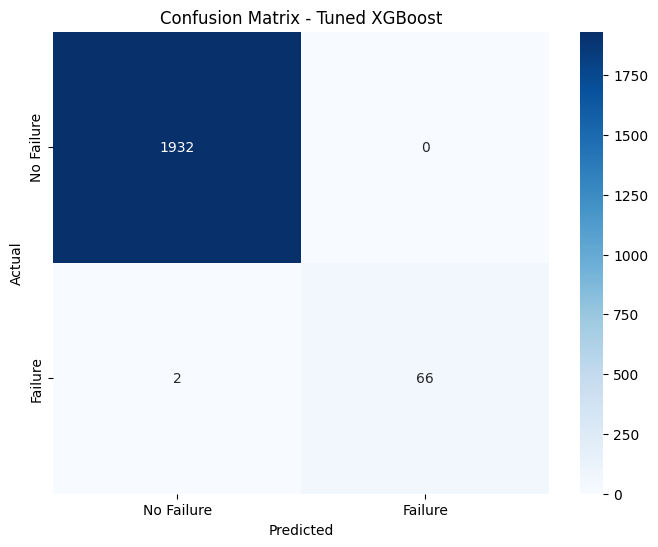

In [49]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

best_xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    alpha=random_search_xgb.best_params_['alpha'],
    colsample_bytree=random_search_xgb.best_params_['colsample_bytree'],
    gamma=random_search_xgb.best_params_['gamma'],
    reg_lambda=random_search_xgb.best_params_['lambda'], 
    learning_rate=random_search_xgb.best_params_['learning_rate'],
    max_depth=random_search_xgb.best_params_['max_depth'],
    n_estimators=random_search_xgb.best_params_['n_estimators'],
    scale_pos_weight=random_search_xgb.best_params_['scale_pos_weight'],
    subsample=random_search_xgb.best_params_['subsample']
)

best_xgb.fit(X_train_failure_processed, y_train_failure)

y_pred_xgb_tuned = best_xgb.predict(X_test_failure_processed)

print("Evaluation of Tuned XGBoost Model:")
print(f"Accuracy: {accuracy_score(y_test_failure, y_pred_xgb_tuned):.4f}")
print(f"Precision: {precision_score(y_test_failure, y_pred_xgb_tuned):.4f}")
print(f"Recall: {recall_score(y_test_failure, y_pred_xgb_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test_failure, y_pred_xgb_tuned):.4f}")

cm_xgb_tuned = confusion_matrix(y_test_failure, y_pred_xgb_tuned)
print("\nConfusion Matrix:")
print(cm_xgb_tuned)

print("\nClassification Report:")
print(classification_report(y_test_failure, y_pred_xgb_tuned))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.show()

tuning hyperparameters for logistic regression using randomized search

defining the hyperparameter space to search for Logistic Regression

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, loguniform

param_distributions_logreg = [
    {
        'penalty': ['l1'],
        'C': loguniform(1e-5, 100),
        'solver': ['liblinear', 'saga']
    },
    {
        'penalty': ['l2'],
        'C': loguniform(1e-5, 100),
        'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
    },
    {
        'penalty': ['elasticnet'],
        'C': loguniform(1e-5, 100),
        'solver': ['saga'],
        'l1_ratio': uniform(0, 1)
    },
    {
        'penalty': [None],
        'solver': ['newton-cg', 'lbfgs', 'sag', 'saga']
    }
]

logreg_model = LogisticRegression(random_state=42, class_weight='balanced')

random_search_logreg = RandomizedSearchCV(
    logreg_model,
    param_distributions=param_distributions_logreg,
    n_iter=100,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    error_score='raise'
)

random_search_logreg.fit(X_train_failure_processed, y_train_failure)

print("Best hyperparameters found by Randomized Search for Logistic Regression:")
print(random_search_logreg.best_params_)

best_logreg_model = random_search_logreg.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best hyperparameters found by Randomized Search for Logistic Regression:
{'C': 3.765311476616754, 'l1_ratio': 0.1834347898661638, 'penalty': 'elasticnet', 'solver': 'saga'}


c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


training the Logistic Regression model using the best hyperparameters and evaluate it on the test set

Evaluation of Tuned Logistic Regression Model:
Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9706
F1-Score: 0.9851

Confusion Matrix:
[[1932    0]
 [   2   66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


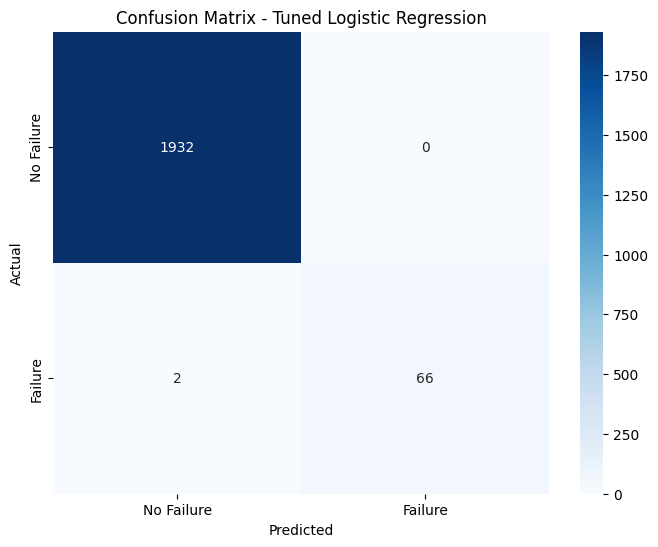

In [51]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

best_logreg = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    C=random_search_logreg.best_params_['C'],
    penalty=random_search_logreg.best_params_['penalty'],
    solver=random_search_logreg.best_params_['solver'],
    l1_ratio=random_search_logreg.best_params_.get('l1_ratio') 
)

best_logreg.fit(X_train_failure_processed, y_train_failure)

y_pred_logreg_tuned = best_logreg.predict(X_test_failure_processed)

print("Evaluation of Tuned Logistic Regression Model:")
print(f"Accuracy: {accuracy_score(y_test_failure, y_pred_logreg_tuned):.4f}")
print(f"Precision: {precision_score(y_test_failure, y_pred_logreg_tuned):.4f}")
print(f"Recall: {recall_score(y_test_failure, y_pred_logreg_tuned):.4f}")
print(f"F1-Score: {f1_score(y_test_failure, y_pred_logreg_tuned):.4f}")

cm_logreg_tuned = confusion_matrix(y_test_failure, y_pred_logreg_tuned)
print("\nConfusion Matrix:")
print(cm_logreg_tuned)

print("\nClassification Report:")
print(classification_report(y_test_failure, y_pred_logreg_tuned))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned Logistic Regression')
plt.show()

creating an ensemble(hybrid) using hard voting for both tuned logistic regression and xgboost

refining the ensemble definition to include a higher max_iter for the Logistic Regression model

c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:23:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluation of Final Hard Voting Ensemble Model:
Accuracy: 0.9990
Precision: 1.0000
Recall: 0.9706
F1-Score: 0.9851

Confusion Matrix:
[[1932    0]
 [   2   66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



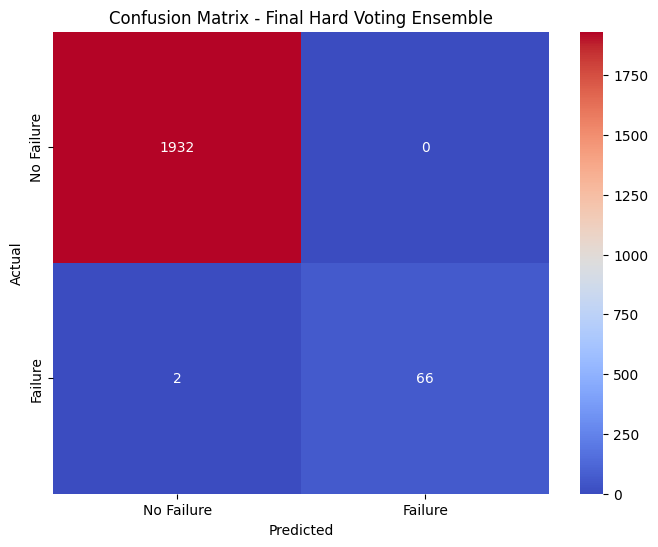

In [52]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
import seaborn as sns
import matplotlib.pyplot as plt

best_logreg_final = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    C=random_search_logreg.best_params_['C'],
    penalty=random_search_logreg.best_params_['penalty'],
    solver=random_search_logreg.best_params_['solver'],
    l1_ratio=random_search_logreg.best_params_.get('l1_ratio'),
    max_iter=1000  
)

best_xgb_final = best_xgb

ensemble_model_final = VotingClassifier(estimators=[
    ('logreg', best_logreg_final),
    ('xgb', best_xgb_final)
], voting='hard')

ensemble_model_final.fit(X_train_failure_processed, y_train_failure)

y_pred_ensemble_final = ensemble_model_final.predict(X_test_failure_processed)

print("Evaluation of Final Hard Voting Ensemble Model:")
print(f"Accuracy: {accuracy_score(y_test_failure, y_pred_ensemble_final):.4f}")
print(f"Precision: {precision_score(y_test_failure, y_pred_ensemble_final):.4f}")
print(f"Recall: {recall_score(y_test_failure, y_pred_ensemble_final):.4f}")
print(f"F1-Score: {f1_score(y_test_failure, y_pred_ensemble_final):.4f}")

cm_ensemble_final = confusion_matrix(y_test_failure, y_pred_ensemble_final)
print("\nConfusion Matrix:")
print(cm_ensemble_final)

print("\nClassification Report:")
print(classification_report(y_test_failure, y_pred_ensemble_final))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ensemble_final, annot=True, fmt='d', cmap='coolwarm',
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Final Hard Voting Ensemble')
plt.show()

saving the preprocessor_classification.joblib and best_hybrid_classifier.joblib

In [53]:
import joblib
joblib.dump(preprocessor_classification, 'preprocessor_classification.joblib')
print("Classification preprocessor (ColumnTransformer) saved as 'preprocessor_classification.joblib'")

joblib.dump(ensemble_model_final, 'best_hybrid_classifier.joblib')
print("Trained ensemble model saved as 'best_hybrid_classifier.joblib'")

Classification preprocessor (ColumnTransformer) saved as 'preprocessor_classification.joblib'
Trained ensemble model saved as 'best_hybrid_classifier.joblib'


REGRESSION METHOD : making a regression model for finding toolwear

Defining df_regression

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd

df_regression = df_ml_failure.copy()

separate target and features for regression

In [55]:
y_regression = df_regression['ToolWear']
X_regression = df_regression[['AirTemperature', 'ProcessTemperature', 'RotationalSpeed', 'Torque', 'Type_L', 'Type_M']]
numerical_features_regression = ['AirTemperature', 'ProcessTemperature', 'RotationalSpeed', 'Torque']
categorical_features_regression = [] 

identifying numerical and categorical features for regression

In [56]:
numerical_features_regression = ['AirTemperature', 'ProcessTemperature', 'RotationalSpeed', 'Torque']
categorical_features_regression = [] 

creating a processing pipeline

In [57]:
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

creating a column transformer

In [58]:
preprocessor_regression = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features_regression)],
    remainder='passthrough') 

splitting the data into training and testing set

In [59]:
X_train_regression, X_test_regression, y_train_regression, y_test_regression = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)

Fiting and transforming the training data, and transforming the test data

In [60]:
X_train_processed_regression = preprocessor_regression.fit_transform(X_train_regression)
X_test_processed_regression = preprocessor_regression.transform(X_test_regression)

In [61]:
print(preprocessor_regression)

ColumnTransformer(remainder='passthrough',
                  transformers=[('num', StandardScaler(),
                                 ['AirTemperature', 'ProcessTemperature',
                                  'RotationalSpeed', 'Torque'])])


saving the preprocessor_regression joblib file

In [62]:
import joblib
joblib.dump(preprocessor_regression, 'preprocessor_regression.joblib')
print("preprocessor_regression saved!")

preprocessor_regression saved!


Converting processed data back to DataFrames

In [63]:
X_train_processed_regression_df = pd.DataFrame(X_train_processed_regression, columns=preprocessor_regression.get_feature_names_out(X_train_regression.columns))
X_test_processed_regression_df = pd.DataFrame(X_test_processed_regression, columns=preprocessor_regression.get_feature_names_out(X_test_regression.columns))

print("Processed Training Data:")
print(X_train_processed_regression_df.head())
print("\nProcessed Testing Data:")
print(X_test_processed_regression_df.head())
print("\nTraining Target:")
print(y_train_regression.head())
print("\nTesting Target:")
print(y_test_regression.head())

Processed Training Data:
   num__AirTemperature  num__ProcessTemperature  num__RotationalSpeed  \
0            -0.854066                -0.609588             -0.136774   
1            -0.904013                -1.080527             -0.136774   
2            -0.904013                -1.484193             -0.136774   
3             0.444570                 0.534121             -0.136774   
4             0.694309                 0.332290             -0.136774   

   num__Torque  remainder__Type_L  remainder__Type_M  
0    -0.892697                1.0                0.0  
1     1.382185                1.0                0.0  
2    -0.892697                1.0                0.0  
3    -0.702287                0.0                1.0  
4    -0.612094                1.0                0.0  

Processed Testing Data:
   num__AirTemperature  num__ProcessTemperature  num__RotationalSpeed  \
0             0.394623                 0.197735             -0.136774   
1             1.793153             

TRAINING A REGRESSION ALGORITHM

TRAINING A RANDOM FOREST REGRESSOR

In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Initializing the random forest regressor model

In [65]:
rf_model = RandomForestRegressor(random_state=42) 

Training the random forest regressor model

In [66]:
rf_model.fit(X_train_processed_regression, y_train_regression)

RandomForestRegressor(random_state=42)

Making predictions on the processed test data

In [67]:
y_pred_rf = rf_model.predict(X_test_processed_regression)

Evaluating the random forest regressor model

In [68]:
mse_rf = mean_squared_error(y_test_regression, y_pred_rf)
r2_rf = r2_score(y_test_regression, y_pred_rf)
mae_rf = mean_absolute_error(y_test_regression, y_pred_rf)

print("Evaluation of Random Forest Regressor Model:")
print(f"Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"R-squared (R2): {r2_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")

Evaluation of Random Forest Regressor Model:
Mean Squared Error (MSE): 0.4496
R-squared (R2): 0.0118
Mean Absolute Error (MAE): 0.5127


seting up the parameter grid and performing the randomized search

In [70]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid_rf = {
    'n_estimators': [int(n) for n in np.linspace(start=200, stop=2000, num=10)],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [int(d) for d in np.linspace(10, 110, num=11)] + [None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_model_tune = RandomForestRegressor(random_state=42)

random_search_rf = RandomizedSearchCV(
    estimator=rf_model_tune,
    param_distributions=param_grid_rf,
    n_iter=30, 
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

random_search_rf.fit(X_train_processed_regression, y_train_regression)

print("Best hyperparameters found by Randomized Search for Random Forest:")
print(random_search_rf.best_params_)

best_rf_model = random_search_rf.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best hyperparameters found by Randomized Search for Random Forest:
{'n_estimators': 1800, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 90, 'bootstrap': True}


training a Random Forest Regressor using the optimized hyperparameters

In [71]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

best_rf_model = RandomForestRegressor(
    n_estimators=random_search_rf.best_params_['n_estimators'],
    min_samples_split=random_search_rf.best_params_['min_samples_split'],
    min_samples_leaf=random_search_rf.best_params_['min_samples_leaf'],
    max_features=random_search_rf.best_params_['max_features'],
    max_depth=random_search_rf.best_params_['max_depth'],
    bootstrap=random_search_rf.best_params_['bootstrap'],
    random_state=42
)

best_rf_model.fit(X_train_processed_regression, y_train_regression)

y_pred_best_rf = best_rf_model.predict(X_test_processed_regression)

mse_best_rf = mean_squared_error(y_test_regression, y_pred_best_rf)
r2_best_rf = r2_score(y_test_regression, y_pred_best_rf)
mae_best_rf = mean_absolute_error(y_test_regression, y_pred_best_rf)

print("Evaluation of Tuned Random Forest Regressor Model:")
print(f"Mean Squared Error (MSE): {mse_best_rf:.4f}")
print(f"R-squared (R2): {r2_best_rf:.4f}")
print(f"Mean Absolute Error (MAE): {mae_best_rf:.4f}")

Evaluation of Tuned Random Forest Regressor Model:
Mean Squared Error (MSE): 0.4418
R-squared (R2): 0.0290
Mean Absolute Error (MAE): 0.4931


training a LightGBM Regressor

In [72]:
!pip install lightgbm


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

lgbm_model = LGBMRegressor(random_state=42)

lgbm_model.fit(X_train_processed_regression, y_train_regression)

y_pred_lgbm = lgbm_model.predict(X_test_processed_regression)

mse_lgbm = mean_squared_error(y_test_regression, y_pred_lgbm)
r2_lgbm = r2_score(y_test_regression, y_pred_lgbm)
mae_lgbm = mean_absolute_error(y_test_regression, y_pred_lgbm)

print("Evaluation of LightGBM Regressor Model (Default Hyperparameters):")
print(f"Mean Squared Error (MSE): {mse_lgbm:.4f}")
print(f"R-squared (R2): {r2_lgbm:.4f}")
print(f"Mean Absolute Error (MAE): {mae_lgbm:.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000743 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] Start training from score -0.000250
Evaluation of LightGBM Regressor Model (Default Hyperparameters):
Mean Squared Error (MSE): 0.4351
R-squared (R2): 0.0438
Mean Absolute Error (MAE): 0.4912


c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


seting up the parameter grid and performing the randomized search for LightGBM

In [74]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid_lgbm = {
    'n_estimators': [int(n) for n in np.linspace(start=100, stop=1000, num=10)],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'num_leaves': [int(n) for n in np.linspace(20, 150, num=10)],
    'max_depth': [int(d) for d in np.linspace(5, 25, num=6)] + [-1], 
    'min_child_samples': [10, 20, 30, 50, 100],
    'subsample': np.linspace(0.7, 1.0, num=4),
    'colsample_bytree': np.linspace(0.6, 1.0, num=5)
}

lgbm_model_tune = LGBMRegressor(random_state=42)

random_search_lgbm = RandomizedSearchCV(
    estimator=lgbm_model_tune,
    param_distributions=param_grid_lgbm,
    n_iter=100, 
    cv=5,       
    verbose=2,
    random_state=42,
    n_jobs=-1,  
    scoring='r2' 
)

random_search_lgbm.fit(X_train_processed_regression, y_train_regression)

print("Best hyperparameters found by Randomized Search for LightGBM:")
print(random_search_lgbm.best_params_)

best_lgbm_model = random_search_lgbm.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000517 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] Start training from score -0.000250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

training a LightGBM Regressor using these optimized hyperparameters and evaluating its performance on the test set

In [75]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

best_lgbm_model = LGBMRegressor(
    subsample=random_search_lgbm.best_params_['subsample'],
    num_leaves=random_search_lgbm.best_params_['num_leaves'],
    n_estimators=random_search_lgbm.best_params_['n_estimators'],
    min_child_samples=random_search_lgbm.best_params_['min_child_samples'],
    max_depth=random_search_lgbm.best_params_['max_depth'],
    learning_rate=random_search_lgbm.best_params_['learning_rate'],
    colsample_bytree=random_search_lgbm.best_params_['colsample_bytree'],
    random_state=42
)

best_lgbm_model.fit(X_train_processed_regression, y_train_regression)

y_pred_best_lgbm = best_lgbm_model.predict(X_test_processed_regression)

mse_best_lgbm = mean_squared_error(y_test_regression, y_pred_best_lgbm)
r2_best_lgbm = r2_score(y_test_regression, y_pred_best_lgbm)
mae_best_lgbm = mean_absolute_error(y_test_regression, y_pred_best_lgbm)

print("Evaluation of Tuned LightGBM Regressor Model:")
print(f"Mean Squared Error (MSE): {mse_best_lgbm:.4f}")
print(f"R-squared (R2): {r2_best_lgbm:.4f}")
print(f"Mean Absolute Error (MAE): {mae_best_lgbm:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000978 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] Start training from score -0.000250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


furthur hyperparameter tuning

In [76]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

param_grid_lgbm_refined = {
    'n_estimators': [int(n) for n in np.linspace(start=400, stop=600, num=5)], 
    'learning_rate': np.linspace(0.005, 0.015, num=5), 
    'num_leaves': [int(n) for n in np.linspace(60, 90, num=7)], 
    'max_depth': [int(d) for d in np.linspace(10, 16, num=7)] + [-1], 
    'min_child_samples': [5, 10, 15], 
    'subsample': np.linspace(0.65, 0.75, num=5), 
    'colsample_bytree': np.linspace(0.85, 0.95, num=5) 
}

lgbm_model_tune_refined = LGBMRegressor(random_state=42)

random_search_lgbm_refined = RandomizedSearchCV(
    estimator=lgbm_model_tune_refined,
    param_distributions=param_grid_lgbm_refined,
    n_iter=100, 
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

random_search_lgbm_refined.fit(X_train_processed_regression, y_train_regression)

print("Best hyperparameters found by Refined Randomized Search for LightGBM:")
print(random_search_lgbm_refined.best_params_)

best_lgbm_model_refined = random_search_lgbm_refined.best_estimator_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000418 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] Start training from score -0.000250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best hyperparameters found by Refined Randomized Search for LightGBM:
{'

training the finetuned model using the best found parameters 

In [77]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

best_lgbm_model_refined = LGBMRegressor(
    subsample=random_search_lgbm_refined.best_params_['subsample'],
    num_leaves=random_search_lgbm_refined.best_params_['num_leaves'],
    n_estimators=random_search_lgbm_refined.best_params_['n_estimators'],
    min_child_samples=random_search_lgbm_refined.best_params_['min_child_samples'],
    max_depth=random_search_lgbm_refined.best_params_['max_depth'],
    learning_rate=random_search_lgbm_refined.best_params_['learning_rate'],
    colsample_bytree=random_search_lgbm_refined.best_params_['colsample_bytree'],
    random_state=42
)

best_lgbm_model_refined.fit(X_train_processed_regression, y_train_regression)

y_pred_best_lgbm_refined = best_lgbm_model_refined.predict(X_test_processed_regression)

mse_best_lgbm_refined = mean_squared_error(y_test_regression, y_pred_best_lgbm_refined)
r2_best_lgbm_refined = r2_score(y_test_regression, y_pred_best_lgbm_refined)
mae_best_lgbm_refined = mean_absolute_error(y_test_regression, y_pred_best_lgbm_refined)

print("Evaluation of Refined Tuned LightGBM Regressor Model:")
print(f"Mean Squared Error (MSE): {mse_best_lgbm_refined:.4f}")
print(f"R-squared (R2): {r2_best_lgbm_refined:.4f}")
print(f"Mean Absolute Error (MAE): {mae_best_lgbm_refined:.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000328 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 444
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 6
[LightGBM] [Info] Start training from score -0.000250
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Evaluation of Refined Tuned LightGBM Regressor Model:
Mean Squared Error (MSE): 0.4256
R-squared (R2): 0.0646
Mean Absolute Error (MAE)

c:\Users\Ona\Documents\CAPSTONEPROJECT_FINAL\capstone\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


performing ensemble using random forest regressor and lightgbm using weighted averaging

In [78]:
weight_lgbm = 0.7
weight_rf = 0.3

y_pred_hybrid_weighted = (weight_lgbm * y_pred_best_lgbm_refined + weight_rf * y_pred_best_rf)

mse_hybrid_weighted = mean_squared_error(y_test_regression, y_pred_hybrid_weighted)
r2_hybrid_weighted = r2_score(y_test_regression, y_pred_hybrid_weighted)
mae_hybrid_weighted = mean_absolute_error(y_test_regression, y_pred_hybrid_weighted)

print("Evaluation of Weighted Averaged Hybrid Model (LGBM: 0.7, RF: 0.3):")
print(f"Mean Squared Error (MSE): {mse_hybrid_weighted:.4f}")
print(f"R-squared (R2): {r2_hybrid_weighted:.4f}")
print(f"Mean Absolute Error (MAE): {mae_hybrid_weighted:.4f}")

Evaluation of Weighted Averaged Hybrid Model (LGBM: 0.7, RF: 0.3):
Mean Squared Error (MSE): 0.4281
R-squared (R2): 0.0592
Mean Absolute Error (MAE): 0.4767


 Regression Model (Tuned LightGBM for ToolWear)

In [79]:
import joblib

joblib.dump(best_lgbm_model_refined, 'best_lgbm_regressor.joblib')

print("Best LightGBM regression model saved as 'best_lgbm_regressor.joblib'")

Best LightGBM regression model saved as 'best_lgbm_regressor.joblib'


Examining feature importance of the final lightGBM regression model

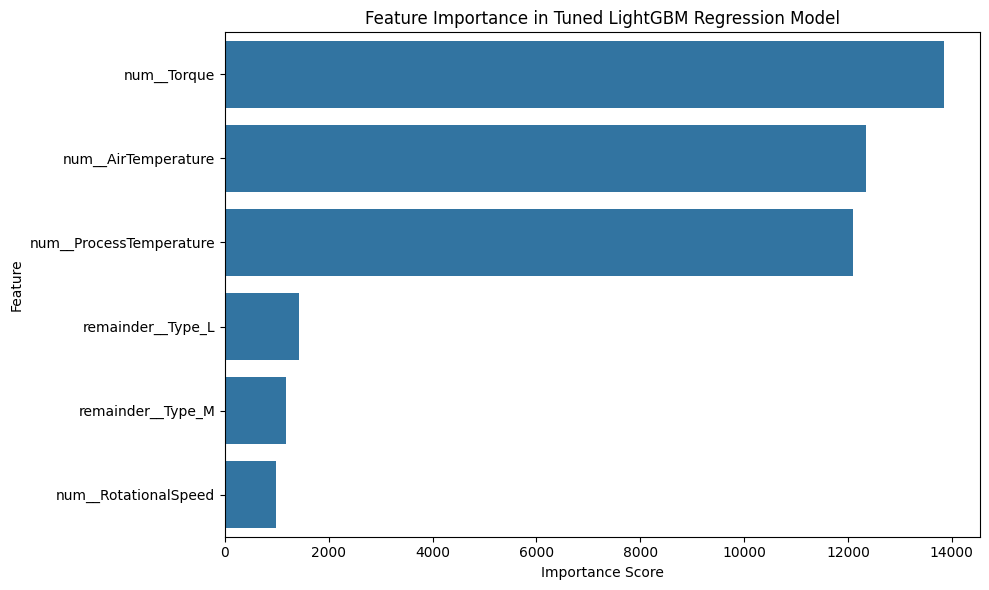

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances_lgbm = best_lgbm_model_refined.feature_importances_

feature_names_regression = preprocessor_regression.get_feature_names_out()

sorted_indices_lgbm = feature_importances_lgbm.argsort()[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_lgbm[sorted_indices_lgbm], y=feature_names_regression[sorted_indices_lgbm])
plt.title('Feature Importance in Tuned LightGBM Regression Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Visualising predictions against actual values for the lightGBM regression model

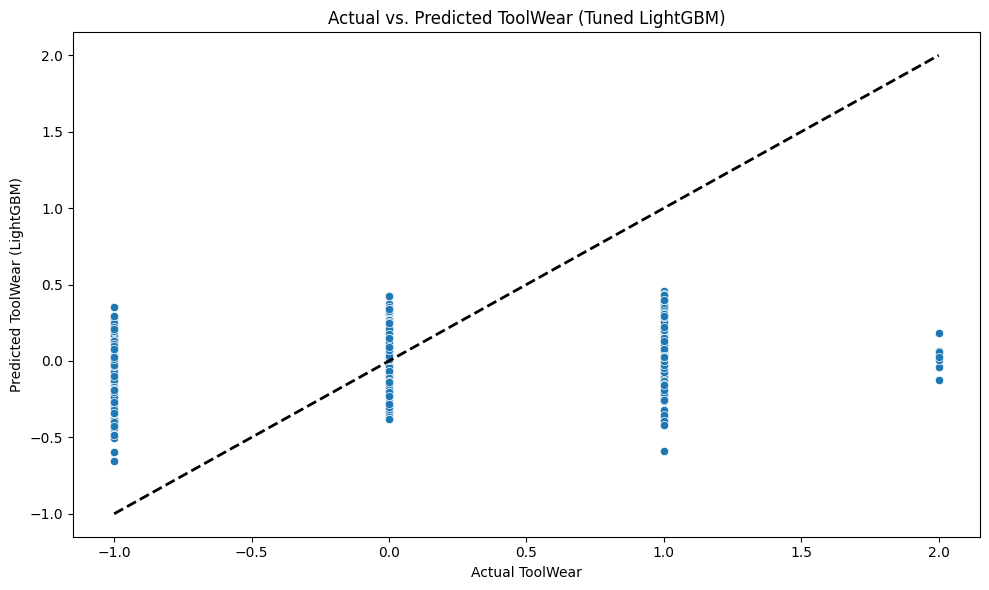

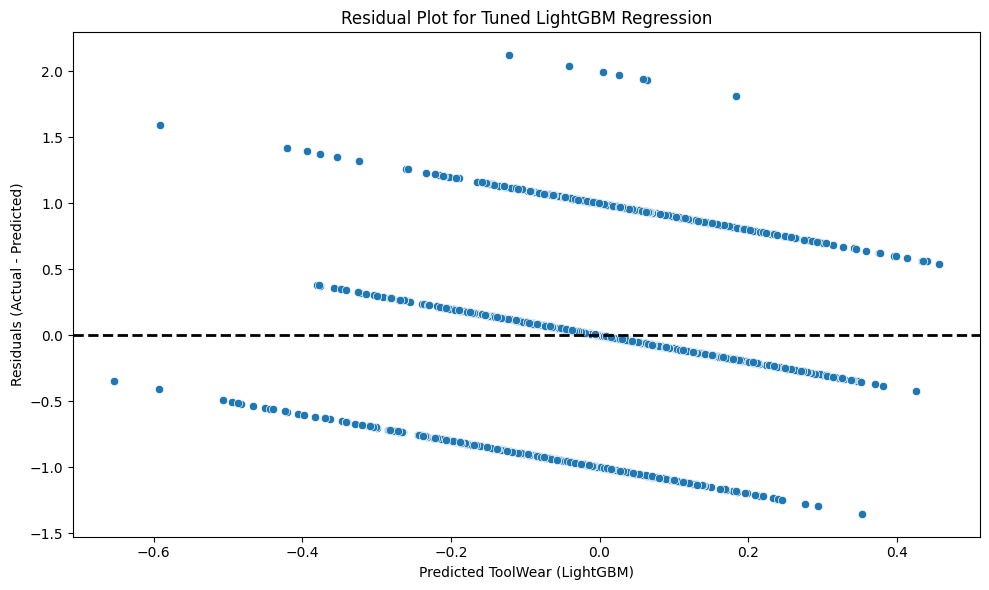

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_regression, y=y_pred_best_lgbm_refined)
plt.xlabel('Actual ToolWear')
plt.ylabel('Predicted ToolWear (LightGBM)')
plt.title('Actual vs. Predicted ToolWear (Tuned LightGBM)')
plt.plot([y_test_regression.min(), y_test_regression.max()], [y_test_regression.min(), y_test_regression.max()], 'k--', lw=2) 
plt.tight_layout()
plt.show()

residuals_lgbm = y_test_regression - y_pred_best_lgbm_refined
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best_lgbm_refined, y=residuals_lgbm)
plt.xlabel('Predicted ToolWear (LightGBM)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot for Tuned LightGBM Regression')
plt.axhline(y=0, color='k', linestyle='--', lw=2)
plt.tight_layout()
plt.show()

calculating root mean squared error (RMSE) for the lightGBM regression model

In [82]:
import numpy as np
from sklearn.metrics import mean_squared_error

rmse_lgbm = np.sqrt(mean_squared_error(y_test_regression, y_pred_best_lgbm_refined))
print(f"Root Mean Squared Error (RMSE) for Tuned LightGBM Regression: {rmse_lgbm:.4f}")

Root Mean Squared Error (RMSE) for Tuned LightGBM Regression: 0.6524


CLASSIFICATION

saving the best trained hybrid classification model

In [83]:
import joblib

joblib.dump(ensemble_model_final, 'best_hybrid_classifier.joblib')

print("Best hybrid classification model saved as 'best_hybrid_classifier.joblib'")

Best hybrid classification model saved as 'best_hybrid_classifier.joblib'


Examining the feature importance of the hybrid classification model

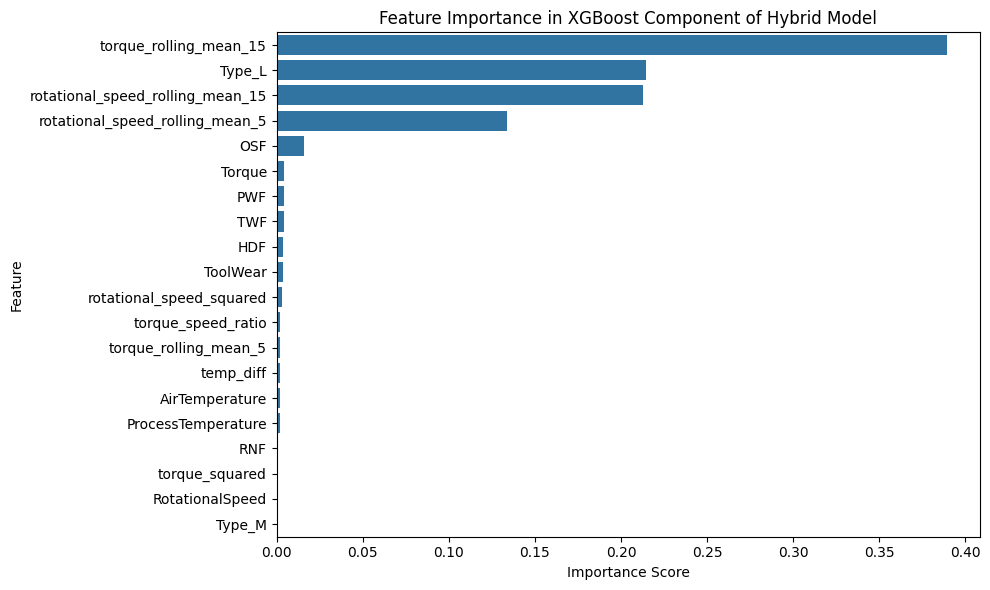

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

if hasattr(ensemble_model_final.named_estimators_['xgb'], 'feature_importances_'):
    feature_importances_xgb = ensemble_model_final.named_estimators_['xgb'].feature_importances_
    feature_names_classification = X_train_failure.columns 
    sorted_indices_xgb = feature_importances_xgb.argsort()[::-1]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances_xgb[sorted_indices_xgb], y=feature_names_classification[sorted_indices_xgb])
    plt.title('Feature Importance in XGBoost Component of Hybrid Model')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
elif hasattr(ensemble_model_final.named_estimators_['logreg'], 'coef_'):
    feature_importances_logreg = ensemble_model_final.named_estimators_['logreg'].coef_[0]
    feature_names_classification = X_train_failure.columns
    sorted_indices_logreg = np.argsort(np.abs(feature_importances_logreg))[::-1]
    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances_logreg[sorted_indices_logreg], y=feature_names_classification[sorted_indices_logreg])
    plt.title('Feature Importance in Logistic Regression Component of Hybrid Model')
    plt.xlabel('Coefficient Value')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance is not directly accessible for this hybrid model configuration.")
    print("Consider examining feature importances of the individual models (Logistic Regression coefficients, XGBoost feature importances) if needed.")

Visualizing predictions of the hybrid classification model (confusion matrix and roc curve) 

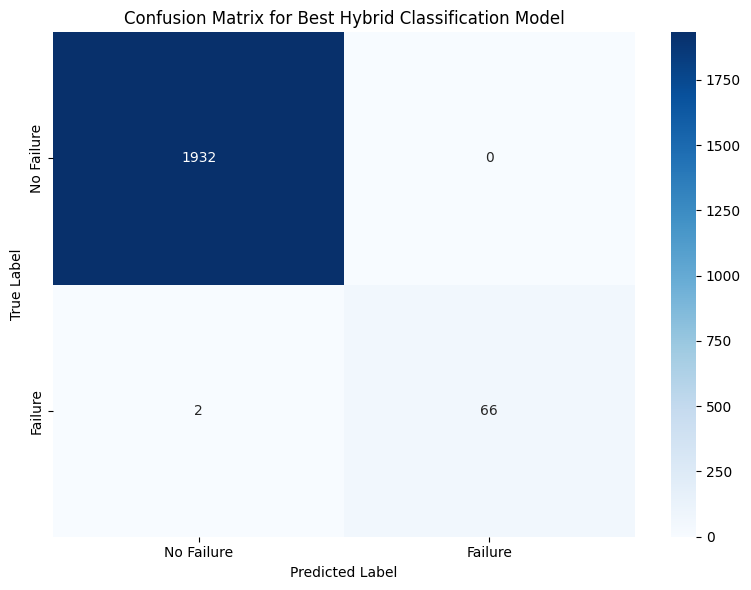

ROC curve is not applicable for this classification task (not binary or no predict_proba method).


In [85]:
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test_failure, y_pred_ensemble_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Failure', 'Failure'], yticklabels=['No Failure', 'Failure'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Best Hybrid Classification Model')
plt.tight_layout()
plt.show()

if len(np.unique(y_test_failure)) == 2 and hasattr(ensemble_model_final, 'predict_proba'):
    y_prob_clf = ensemble_model_final.predict_proba(X_test_failure)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test_failure, y_prob_clf)
    auc_score = roc_auc_score(y_test_failure, y_prob_clf)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Best Hybrid Classification Model')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("ROC curve is not applicable for this classification task (not binary or no predict_proba method).")

calculating other relevant metrics for the hybrid classification model(precision, recall,f1_score, accuracy)

In [86]:
from sklearn.metrics import classification_report, accuracy_score

print("Classification Report for Best Hybrid Classification Model:")
print(classification_report(y_test_failure, y_pred_ensemble_final))

accuracy_clf = accuracy_score(y_test_failure, y_pred_ensemble_final)
print(f"\nAccuracy of Best Hybrid Classification Model: {accuracy_clf:.4f}")

Classification Report for Best Hybrid Classification Model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000


Accuracy of Best Hybrid Classification Model: 0.9990


MACHINE LEARNING MODEL DEPLOYMENT 

In [87]:
!pip install streamlit


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


saving preprocessors for regression and preprocessors for classification 

In [88]:
joblib.dump(preprocessor_regression, 'preprocessor_regression.joblib')

joblib.dump(preprocessor_classification, 'preprocessor_classification.joblib')

['preprocessor_classification.joblib']